### PyTorch 实现 LSTM-CAMELS与训练

本节按如下顺序组织：导入与通用函数（train_epoch、eval_model） → 数据集与模型（CamelsDataset、LSTM_CAMELS） → 数据选择与拆分 → 训练配置与数据装载器 → 模型与优化器 → 训练循环与验证 → 测试集评估与可视化。


### PyTorch 实现 LSTM-CAMELS

本节我们将使用 PyTorch 实现一个两层 LSTM 的 CAMELS 流量预测模型，包含数据集封装 `CamelsDataset` 与模型 `LSTM_CAMELS`，供本笔记本后续训练流程直接引用。


In [ ]:
import numpy as np
import random
import pandas as pd
import xarray as xr
import tqdm
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import HydroErr as he
from matplotlib import pyplot as plt

# 设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")



### 数据集封装：CamelsDataset

该数据集类负责：
- 根据训练/验证模式计算或复用均值与标准差
- 对强迫、属性与流量进行局地归一化
- 构造样本查找表，将三维张量组织为 LSTM 的输入输出


In [29]:
class CamelsDataset(Dataset):
    """Base data set class to load and preprocess data (batch-first) using PyTroch's Dataset"""

    def __init__(
        self,
        basins: list,
        dates: list,
        data_attr: pd.DataFrame,
        data_forcing: xr.Dataset,
        data_flow: xr.Dataset,
        loader_type: str = "train",
        seq_length: int = 100,
        means: pd.DataFrame = None,
        stds: pd.DataFrame = None,
    ):
        super(CamelsDataset, self).__init__()
        if loader_type not in ["train", "valid", "test"]:
            raise ValueError(" 'loader_type' must be one of 'train', 'valid' or 'test' ")
        else:
            self.loader_type = loader_type
        self.basins = basins
        self.dates = dates

        self.seq_length = seq_length

        self.means = means
        self.stds = stds

        self.data_attr = data_attr
        self.data_forcing = data_forcing
        self.data_flow = data_flow

        # load and preprocess data
        self._load_data()

    def __len__(self):
        return self.num_samples

    def __getitem__(self, item: int):
        basin, time = self.lookup_table[item]
        seq_length = self.seq_length
        x = (
            self.x.sel(
                basin=basin,
                time=slice(time, time + np.timedelta64(seq_length - 1, "D")),
            )
            .to_array()
            .to_numpy()
        ).T
        c = self.c.loc[basin].values
        c = np.tile(c, (seq_length, 1))
        xc = np.concatenate((x, c), axis=1)
        y = (
            self.y.sel(
                basin=basin,
                time=time + np.timedelta64(seq_length - 1, "D"),
            )
            .to_array()
            .to_numpy()
        )
        return torch.from_numpy(xc).float(), torch.from_numpy(y).float()

    def _load_data(self):
        """load data from nc and feather files"""
        if self.loader_type == "train":
            train_mode = True
            df_mean_forcings = self.data_forcing.mean().to_pandas()
            df_std_forcings = self.data_forcing.std().to_pandas()
            df_mean_streamflow = self.data_flow.mean().to_pandas()
            df_std_streamflow = self.data_flow.std().to_pandas()
            df_mean_attr = self.data_attr.mean()
            df_std_attr = self.data_attr.std()
            self.means = pd.concat([df_mean_forcings, df_mean_attr, df_mean_streamflow])
            self.stds = pd.concat([df_std_forcings, df_std_attr, df_std_streamflow])
        else:
            train_mode = False

        # nomalization
        self.x = self._local_normalization(self.data_forcing, list(self.data_forcing.keys()))
        self.c = self._local_normalization(self.data_attr, self.data_attr.columns.values.tolist())
        if train_mode:
            self.y = self._local_normalization(self.data_flow, list(self.data_flow.keys()))
        else:
            self.y = self.data_flow
        self.train_mode = train_mode
        self._create_lookup_table()

    def _local_normalization(self, feature, variable) -> np.ndarray:
        """Normalize features with local mean/std."""
        feature = (feature - self.means[variable]) / self.stds[variable]
        return feature

    def _create_lookup_table(self):
        """create a index table for __getitem__ functions"""
        lookup = []
        seq_length = self.seq_length
        dates = self.data_flow["time"].to_numpy()
        time_length = len(dates)
        for basin in self.basins:
            for j in range(time_length - seq_length + 1):
                lookup.append((basin, dates[j]))
        self.lookup_table = {i: elem for i, elem in enumerate(lookup)}
        self.num_samples = len(self.lookup_table)

    def get_means(self):
        return self.means

    def get_stds(self):
        return self.stds

    def local_denormalization(self, feature, variable="streamflow"):
        """revert the normalization for streaflow"""
        feature = feature * self.stds[variable] + self.means[variable]
        return feature


### 模型：LSTM_CAMELS

两层 LSTM，末端接全连接层，仅使用最后时刻隐藏状态进行回归预测。


In [30]:
class LSTM_CAMELS(nn.Module):
    """Implementation of a two-layer LSTM network"""

    def __init__(self, input_size, hidden_size: int, dropout_rate: float = 0.0):
        super(LSTM_CAMELS, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            bias=True,
            batch_first=True,
        )
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc = nn.Linear(in_features=hidden_size, out_features=1)

        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output, (h_n, c_n) = self.lstm(x)
        pred = self.fc(self.dropout(h_n[-1, :, :]))
        return pred


### 训练与验证

本节包含训练单轮函数、评估函数、数据选择与拆分、训练循环，以及测试集评价与可视化示例。

In [ ]:
def train_epoch(model, optimizer, loader, loss_func, epoch):
    """Train model for a single epoch"""
    # TODO: 请学生在此处补充训练函数的完整实现
    # 提示：
    # 1. 设置模型为训练模式
    # 2. 遍历数据加载器中的每个批次
    # 3. 对每个批次：清零梯度、前向传播、计算损失、反向传播、更新参数
    # 4. 可选：使用 tqdm 显示训练进度
    pass

def eval_model(model, loader):
    """Evaluate the model"""
    model.eval()
    obs = []
    preds = []
    with torch.no_grad():
        for xs, ys in loader:
            xs = xs.to(device)
            y_hat = model(xs)
            obs.append(ys)
            preds.append(y_hat)
    return torch.cat(obs), torch.cat(preds)


### 数据选择与拆分

默认：通过单个索引选择一个流域。可通过修改流域索引或自定义列表来切换不同流域。

- 随机种子：建议每位同学自定义不同的 seed，用于数据拆分、初始化与打乱，避免作业结果雷同。

备选：
- 选取前 `basins_num` 个流域
- 选取索引区间 `[start_idx:end_idx)` 的一段流域

也可按需调整 `train_times`/`valid_times`/`test_times` 与 `chosen_forcing_vars`/`chosen_attrs_vars`，以优化训练与评估效果。


In [ ]:
def set_random_seed(seed):
    print("Random seed:", seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 可自定义：请每位同学使用不同的 seed 以避免作业雷同
seed = 2025
set_random_seed(seed)

# 默认：选择前 basins_num 个流域
basins_num = 2
chosen_basins = camels_us.camels_sites["gauge_id"][:basins_num].values

# 备选：选择索引区间 [start_idx:end_idx) 的一段流域
# start_idx, end_idx = 0, 5
# chosen_basins = camels_us.camels_sites["gauge_id"][start_idx:end_idx].values
# basins_num = len(chosen_basins)

train_times = ["1990-09-01", "2000-08-31"]
valid_times = ["2000-09-01", "2005-08-31"]
test_times  = ["2005-09-01", "2010-08-31"]

chosen_forcing_vars = ["dayl", "prcp", "srad", "tmax", "tmin", "vp"]
chosen_attrs_vars = [
    "p_mean", "p_seasonality", "frac_snow", "aridity",
    "geol_porostiy", "geol_permeability",
    "soil_depth_statsgo", "soil_porosity", "soil_conductivity",
    "elev_mean", "slope_mean", "area_gages2", "frac_forest", "lai_max",
]

# 需要的属性
a = attrs[attrs["gauge_id"].isin(chosen_basins)][["gauge_id"] + chosen_attrs_vars]
chosen_attrs = a.set_index("gauge_id")

# 强迫数据
train_forcings = forcing_ds[chosen_forcing_vars].sel(basin=chosen_basins, time=slice(train_times[0], train_times[1]))
valid_forcings = forcing_ds[chosen_forcing_vars].sel(basin=chosen_basins, time=slice(valid_times[0], valid_times[1]))
test_forcings  = forcing_ds[chosen_forcing_vars].sel(basin=chosen_basins, time=slice(test_times[0],  test_times[1]))


Random seed: 2025


In [32]:
def load_streamflow(ds_flow, ds_attr, basins, time_range):
    """将 ft3/s 转为 mm/day"""
    chosen_streamflow = ds_flow.sel(basin=basins, time=slice(time_range[0], time_range[1]))
    area = ds_attr["area_gages2"].values
    flow = (
        0.0283168 * chosen_streamflow * 1000 * 86400 / (area.reshape(len(area), 1) * 10**6)
    )
    return flow

# 径流
train_flow = load_streamflow(streamflow_ds, chosen_attrs, chosen_basins, train_times)
valid_flow = load_streamflow(streamflow_ds, chosen_attrs, chosen_basins, valid_times)
test_flow  = load_streamflow(streamflow_ds, chosen_attrs, chosen_basins, test_times)


### 训练配置与数据装载器


In [ ]:
# 输入维度与超参数（可调整以优化训练效果）
sequence_length = 100  # 预测窗口长度，可调整
batch_size = 32        # 批大小，可调整
hidden_size = 10       # LSTM 隐层维度，可调整
learning_rate = 1e-3   # 学习率，可调整

a = len(chosen_attrs_vars)
b = len(chosen_forcing_vars)
input_size = a + b

# 训练/验证数据集与装载器（使用上文 CamelsDataset 类）
ds_train = CamelsDataset(
    basins=chosen_basins,
    dates=train_times,
    data_attr=chosen_attrs,
    data_forcing=train_forcings,
    data_flow=train_flow,
    loader_type="train",
    seq_length=sequence_length,
)
tr_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True)

means = ds_train.get_means()
stds = ds_train.get_stds()

ds_val = CamelsDataset(
    basins=chosen_basins,
    dates=valid_times,
    data_attr=chosen_attrs,
    data_forcing=valid_forcings,
    data_flow=valid_flow,
    loader_type="valid",
    seq_length=sequence_length,
    means=means,
    stds=stds,
)
val_loader = DataLoader(ds_val, batch_size=1000, shuffle=False)


In [34]:
# 创建模型与优化器（使用上文 LSTM_CAMELS 类）
model = LSTM_CAMELS(input_size=input_size, hidden_size=hidden_size, dropout_rate=0.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_func = nn.MSELoss()


### 训练循环与验证


In [ ]:
n_epochs = 2  # 可调整，例如 20/50/100，以获得更充分训练
for i in range(n_epochs):
    train_epoch(model, optimizer, tr_loader, loss_func, i + 1)
    obs, preds = eval_model(model, val_loader)
    preds = ds_val.local_denormalization(preds.cpu().numpy(), variable="streamflow")
    obs = obs.numpy().reshape(basins_num, -1)
    preds = preds.reshape(basins_num, -1)
    nse = np.array([he.nse(preds[i], obs[i]) for i in range(obs.shape[0])])
    tqdm.notebook.tqdm.write(f"Validation NSE mean: {nse.mean():.2f}")


！[tu1](1.png)

### 测试集评估与可视化


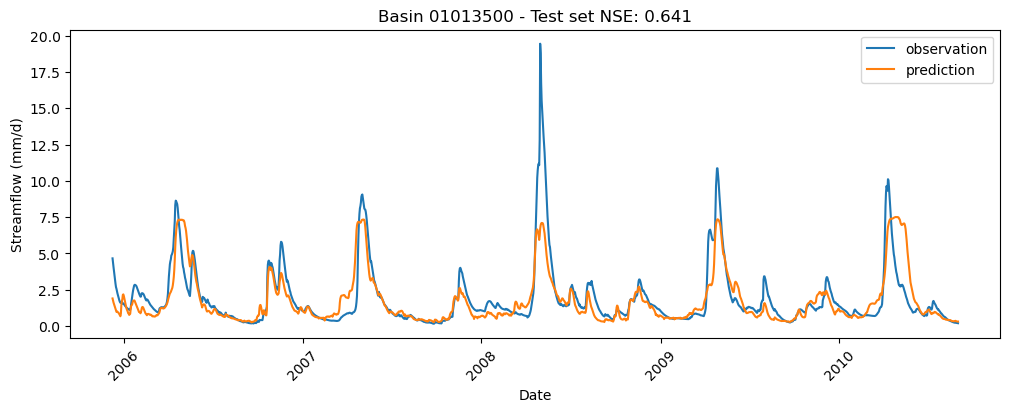

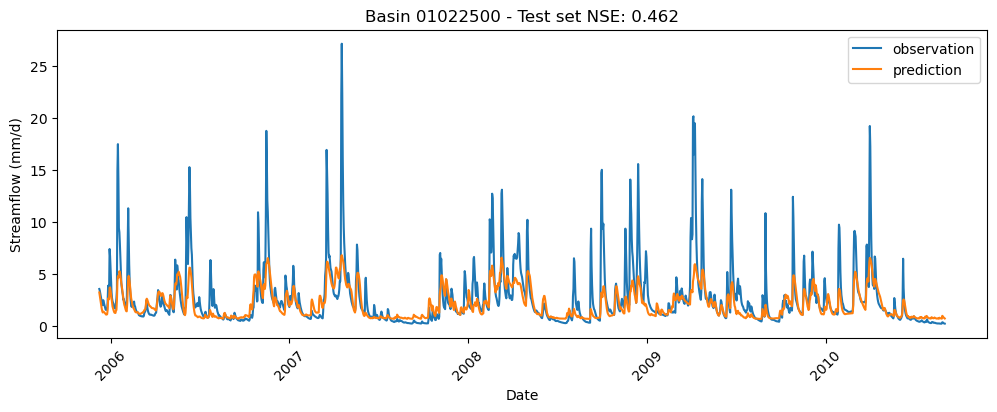

In [36]:
# 测试集装载器
ds_test = CamelsDataset(
    basins=chosen_basins,
    dates=test_times,
    data_attr=chosen_attrs,
    data_forcing=test_forcings,
    data_flow=test_flow,
    loader_type="test",
    seq_length=sequence_length,
    means=means,
    stds=stds,
)

test_loader = DataLoader(ds_test, batch_size=1000, shuffle=False)
obs, preds = eval_model(model, test_loader)
preds = ds_test.local_denormalization(preds.cpu().numpy(), variable="streamflow")
obs = obs.numpy().reshape(basins_num, -1)
preds = preds.reshape(basins_num, -1)
nse = np.array([he.nse(preds[i], obs[i]) for i in range(obs.shape[0])])

# 绘图
start_date = pd.to_datetime(ds_test.dates[0], format="%Y-%m-%d") + pd.DateOffset(days=sequence_length - 1)
end_date = pd.to_datetime(ds_test.dates[1], format="%Y-%m-%d")
date_range = pd.date_range(start_date, end_date)
for i in range(basins_num):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(date_range, obs[i], label="observation")
    ax.plot(date_range, preds[i], label="prediction")
    ax.legend()
    ax.set_title(f"Basin {chosen_basins[i]} - Test set NSE: {nse[i]:.3f}")
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_xlabel("Date")
    _ = ax.set_ylabel("Streamflow (mm/d)")
